<a href="https://colab.research.google.com/github/tejinderpa/Natural-Language-Processing/blob/branch1/BankChurnModelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("/content/Churn_Modelling.csv")
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
3807,3808,15670562,Pharr,470,France,Male,30,3,101140.76,1,1,1,50906.65,0
7611,7612,15705506,Perry,751,Spain,Male,38,7,0.00,2,0,0,90839.61,0
1333,1334,15734942,Nnamutaezinwa,539,Germany,Female,38,8,82407.51,1,1,0,13123.41,0
3086,3087,15674206,Walker,716,France,Female,22,8,0.00,2,1,1,92606.98,0
6455,6456,15701522,Yermolayeva,711,France,Female,29,9,0.00,2,0,1,3234.80,0


In [5]:
var = df.Exited.value_counts()

In [6]:
var

,count
Exited,
0,7963
1,2037


In [7]:
df.shape

(10000, 14)

In [8]:
print("Percentage of rows with Exited = 1: ")
var[1]/df.shape[0]*100

Percentage of rows with Exited = 1: 


np.float64(20.369999999999997)

In [9]:
df.drop('Surname', axis = 'columns', inplace=True)

In [10]:
df.dtypes

,0
RowNumber,int64
CustomerId,int64
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,int64


In [11]:
df

,RowNumber,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


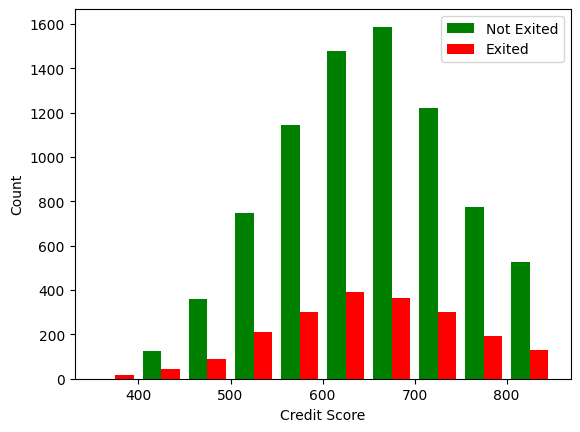

In [12]:
a = df[df.Exited == 0]['CreditScore']
b = df[df.Exited == 1]['CreditScore']
plt.xlabel("Credit Score")
plt.ylabel("Count")

plt.hist([a, b], color=['green', 'red'], label=['Not Exited', 'Exited'])
plt.legend()

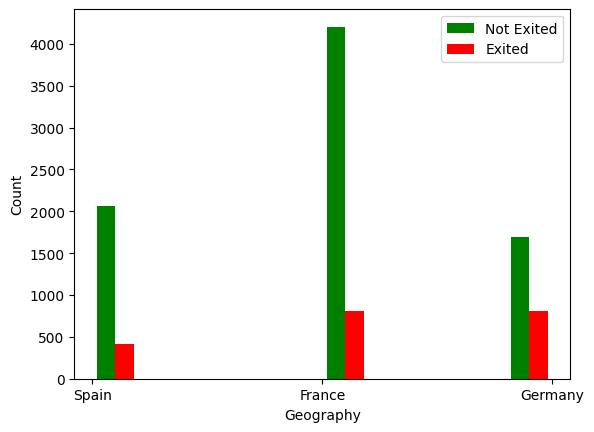

In [13]:
a = df[df.Exited == 0]['Geography']
b = df[df.Exited == 1]['Geography']
plt.xlabel("Geography")
plt.ylabel("Count")

plt.hist([a, b], color=['green', 'red'], label=['Not Exited', 'Exited'])
plt.legend()

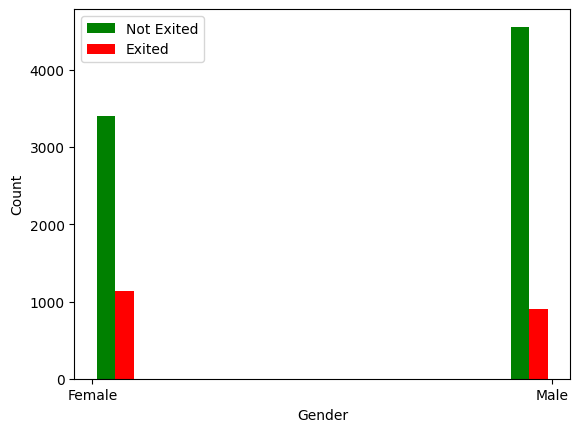

In [14]:
a = df[df.Exited == 0]['Gender']
b = df[df.Exited == 1]['Gender']
plt.xlabel("Gender")
plt.ylabel("Count")

plt.hist([a, b], color=['green', 'red'], label=['Not Exited', 'Exited'])
plt.legend()

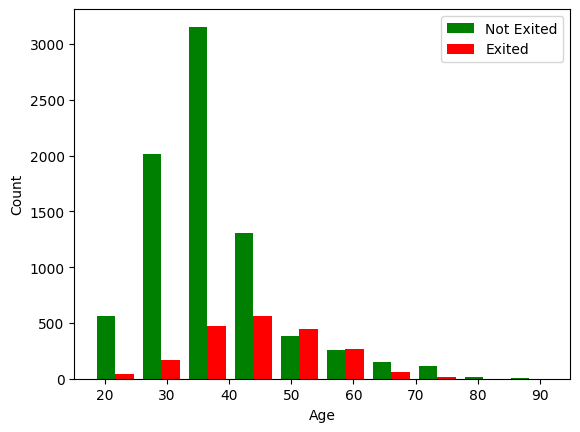

In [15]:
a = df[df.Exited == 0]['Age']
b = df[df.Exited == 1]['Age']
plt.xlabel("Age")
plt.ylabel("Count")

plt.hist([a, b], color=['green', 'red'], label=['Not Exited', 'Exited'])
plt.legend()

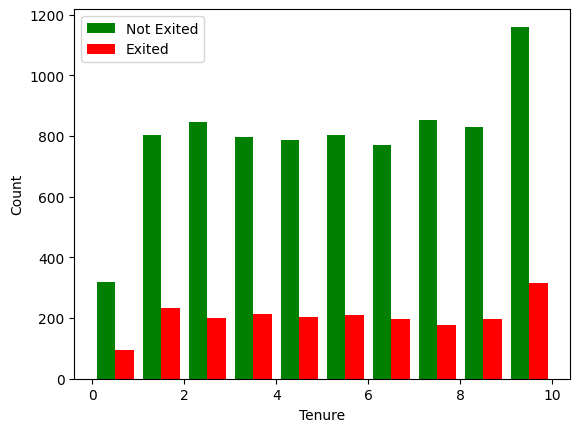

In [16]:
a = df[df.Exited == 0]['Tenure']
b = df[df.Exited == 1]['Tenure']
plt.xlabel("Tenure")
plt.ylabel("Count")

plt.hist([a, b], color=['green', 'red'], label=['Not Exited', 'Exited'])
plt.legend()

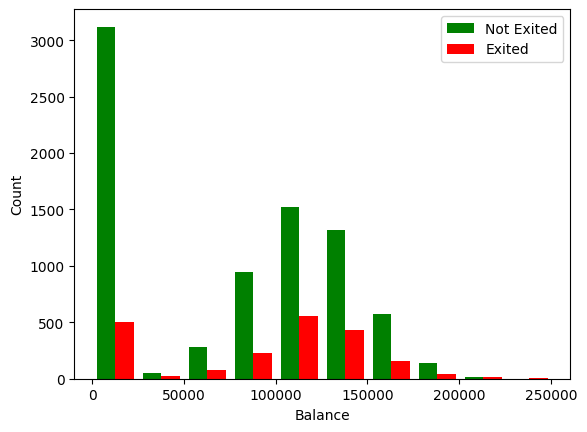

In [17]:
a = df[df.Exited == 0]['Balance']
b = df[df.Exited == 1]['Balance']
plt.xlabel("Balance")
plt.ylabel("Count")

plt.hist([a, b], color=['green', 'red'], label=['Not Exited', 'Exited'])
plt.legend()

In [18]:
def print_unique_col_values(df):
  for column in df:
    if df[column].dtypes == 'object':
      print(f'{column}: {df[column].unique()}')

In [19]:
print_unique_col_values(df)

Geography: ['France' 'Spain' 'Germany']
Gender: ['Female' 'Male']


In [20]:
for col in df:
  print(f'{col}: {df[col].unique()}')

RowNumber: [    1     2     3 ...  9998  9999 10000]
CustomerId: [15634602 15647311 15619304 ... 15584532 15682355 15628319]
CreditScore: [619 608 502 699 850 645 822 376 501 684 528 497 476 549 635 616 653 587
 726 732 636 510 669 846 577 756 571 574 411 591 533 553 520 722 475 490
 804 582 472 465 556 834 660 776 829 637 550 698 585 788 655 601 656 725
 511 614 742 687 555 603 751 581 735 661 675 738 813 657 604 519 664 678
 757 416 665 777 543 506 493 652 750 729 646 647 808 524 769 730 515 773
 814 710 413 623 670 622 785 605 479 685 538 562 721 628 668 828 674 625
 432 770 758 795 686 789 589 461 584 579 663 682 793 691 485 650 754 535
 716 539 706 586 631 717 800 683 704 615 667 484 480 578 512 606 597 778
 514 525 715 580 807 521 759 516 711 618 643 671 689 620 676 572 695 592
 567 694 547 594 673 610 767 763 712 703 662 659 523 772 545 634 739 771
 681 544 696 766 727 693 557 531 498 651 791 733 811 707 714 782 775 799
 602 744 588 747 583 627 731 629 438 642 806 474 559 429 68

In [21]:
cols_to_scale = ['Tenure', 'Balance', 'EstimatedSalary', 'CreditScore', 'Age']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [22]:
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [45]:
for col in df:
  print(f'{col}: {df[col].unique()}')

RowNumber: [    1     2     3 ...  9998  9999 10000]
CustomerId: [15634602 15647311 15619304 ... 15584532 15682355 15628319]
CreditScore: [0.538 0.516 0.304 0.698 1.    0.59  0.944 0.052 0.302 0.668 0.356 0.294
 0.252 0.398 0.57  0.532 0.606 0.474 0.752 0.764 0.572 0.32  0.638 0.992
 0.454 0.812 0.442 0.448 0.122 0.482 0.366 0.406 0.34  0.744 0.25  0.28
 0.908 0.464 0.244 0.23  0.412 0.968 0.62  0.852 0.958 0.574 0.4   0.696
 0.47  0.876 0.61  0.502 0.612 0.75  0.322 0.528 0.784 0.674 0.41  0.506
 0.802 0.462 0.77  0.622 0.65  0.776 0.926 0.614 0.508 0.338 0.628 0.656
 0.814 0.132 0.63  0.854 0.386 0.312 0.286 0.604 0.8   0.758 0.592 0.594
 0.916 0.348 0.838 0.76  0.33  0.846 0.928 0.72  0.126 0.546 0.64  0.544
 0.87  0.51  0.258 0.67  0.376 0.424 0.742 0.556 0.636 0.956 0.648 0.55
 0.164 0.84  0.816 0.89  0.672 0.878 0.478 0.222 0.468 0.458 0.626 0.664
 0.886 0.682 0.27  0.6   0.808 0.37  0.732 0.378 0.712 0.472 0.562 0.734
 0.9   0.666 0.708 0.53  0.634 0.268 0.26  0.456 0.324 0.512 

In [44]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
# Female -> 0, Male -> 1

# 2. One-hot encode 'Geography' (multi-category)
df['Geography'] = le.fit_transform(df['Geography'])
# France -> 0, Spain -> 1, Germany -> 2
# drop_first=True avoids dummy variable trap

In [63]:
X = df.drop(["Exited", "RowNumber", "CustomerId"], axis = 'columns')
y = df.Exited.astype(np.float32)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

In [55]:
y_train.value_counts()

,count
Exited,
0.0,6370
1.0,1630


In [56]:
6370/1630


3.9079754601226995

In [57]:
y_test.value_counts()

,count
Exited,
0.0,1593
1.0,407


In [58]:
X_train.shape, X_test.shape

((8000, 12), (2000, 12))

In [59]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix , classification_report

In [62]:
def ANN(X_train, y_train, X_test, y_test, loss, weights):
    model = keras.Sequential([
        keras.layers.Dense(26, input_dim=X_train.shape[1], activation='relu'),
        keras.layers.Dense(15, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])

    if weights == -1:
        model.fit(X_train, y_train, epochs=50)
    else:
        model.fit(X_train, y_train, epochs=50, class_weight = weights)

    print(model.evaluate(X_test, y_test))

    y_preds = model.predict(X_test)
    y_preds = np.round(y_preds)

    print("Classification Report: \n", classification_report(y_test, y_preds))

    return y_preds

In [64]:
y_preds = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7460 - loss: 0.5446
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7988 - loss: 0.4590
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8099 - loss: 0.4388
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8177 - loss: 0.4225
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8317 - loss: 0.3978
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8279 - loss: 0.4053
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8416 - loss: 0.3888
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8415 - loss: 0.3784
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8411 - loss: 0.3802
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8387 - loss: 0.3727
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8438 - loss: 0.3765
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Data was unbalanced so fixing it
Method1: undersampling


In [65]:
# Class count
count_class_0, count_class_1 = df.Exited.value_counts()

# Divide by class
df_class_0 = df[df['Exited'] == 0]
df_class_1 = df[df['Exited'] == 1]

In [68]:
df_class_0.shape, df_class_1.shape


((7963, 13), (2037, 13))

In [66]:
# Undersample 0-class and concat the DataFrames of both class
df_class_0_under = df_class_0.sample(count_class_1)
df_test_under = pd.concat([df_class_0_under, df_class_1], axis=0)

print('Random under-sampling:')
print(df_test_under.Exited.value_counts())

Random under-sampling:
Exited
0    2037
1    2037
Name: count, dtype: int64


In [69]:
X = df_test_under.drop('Exited',axis='columns')
y = df_test_under['Exited']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

In [70]:
y_train.value_counts()

,count
Exited,
1,1630
0,1629


In [71]:
y_preds = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

Epoch 1/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4954 - loss: 101007.7344
Epoch 2/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5122 - loss: 1693.0837
Epoch 3/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5052 - loss: 1902.6271
Epoch 4/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5123 - loss: 2070.2776
Epoch 5/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5330 - loss: 1337.9014
Epoch 6/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5067 - loss: 2066.0449
Epoch 7/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4812 - loss: 3765.5715
Epoch 8/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4858 - loss: 1765.5696
Epoch 9/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4917 - loss: 1353.6409
Epoch 10/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5054 - loss: 1976.0167
Epoch 11/50
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5055 - loss: 2912.0366
Epoch 12/50
102/

Method-2 : Oversampling

In [72]:
# Oversample 1-class and concat the DataFrames of both classes
df_class_1_over = df_class_1.sample(count_class_0, replace=True)
df_test_over = pd.concat([df_class_0, df_class_1_over], axis=0)

print('Random over-sampling:')
print(df_test_over.Exited.value_counts())


X = df_test_over.drop('Exited',axis='columns')
y = df_test_over['Exited']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15, stratify=y)

Random over-sampling:
Exited
0    7963
1    7963
Name: count, dtype: int64


In [73]:
y_train.value_counts()

,count
Exited,
0,6370
1,6370


In [74]:
loss = keras.losses.BinaryCrossentropy()
weights = -1
y_preds = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5008 - loss: 65343.4062
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4882 - loss: 8542.2100
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4953 - loss: 6369.9541
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4980 - loss: 6713.0513
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5095 - loss: 4430.6040
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4979 - loss: 6488.2290
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5018 - loss: 7112.0815
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5092 - loss: 5268.0029
Epoch 9/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4961 - loss: 5783.1128
Epoch 10/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5021 - loss: 6430.4966
Epoch 11/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5117 - loss: 5665.1758
Epoch 12/50
399/39

In [75]:
X = df.drop('Exited', axis='columns')
y = df['Exited']

In [77]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='minority')
X_sm, y_sm = smote.fit_resample(X, y)

In [78]:
y_sm.value_counts()


,count
Exited,
1,7963
0,7963


In [79]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_sm, y_sm, test_size=0.2, random_state=15, stratify=y_sm)

In [80]:
y_train.value_counts()

,count
Exited,
0,6370
1,6370


In [81]:
y_preds = ANN(X_train, y_train, X_test, y_test, 'binary_crossentropy', -1)

Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4935 - loss: 195532.0469
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5071 - loss: 3522.2134
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4847 - loss: 3484.9922
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5097 - loss: 3900.9958
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5043 - loss: 4147.1304
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4980 - loss: 4093.8245
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5003 - loss: 2985.5557
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5018 - loss: 2141.4053
Epoch 9/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5039 - loss: 4064.8789
Epoch 10/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4992 - loss: 2994.3755
Epoch 11/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5045 - loss: 2897.9055
Epoch 12/50
399/3